<a href="https://colab.research.google.com/github/UtkarshPandey-0/Task-Master-codes/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 70.9 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11427 sha256=beb1a65a9e2ac4c72c810d1b3840e1dfe54cbdba3a3798a1a63b627eac48bc9a
  Stored in directory: /root/.cache/pip/wheels/30/85/d4/289ba063a9ae0ba3189c6914e992722575868b2cb41100401b
  Created wheel for memoization

/usr/local/lib/python3.13/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Found Data:
SearchResult containing 49 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 02 2009 Kepler      60 kplr011904151      0.0
  1 Kepler Quarter 03 2009 Kepler      60 kplr011904151      0.0
  2 Kepler Quarter 03 2009 Kepler      60 kplr011904151      0.0
  3 Kepler Quarter 03 2009 Kepler      60 kplr011904151      0.0
  4 Kepler Quarter 00 2009 Kepler    1800 kplr011904151      0.0
  5 Kepler Quarter 01 2009 Kepler    1800 kplr011904151      0.0
  6 Kepler Quarter 02 2009 Kepler    1800 kplr011904151      0.0
  7 Kepler Quarter 03 2009 Kepler    1800 kplr011904151      0.0
  8 Kepler Quarter 04 2010 Kepler      60 kplr011904151      0.0
  9 Kepler Quarter 05 2010 Kepler      60 kplr011904151      0.0
 10 Kepler Quarter 05 2010 Kepler      60 kplr011904151      0.0
 11 Kepler Quarter 05 2010 Kepler  

<Axes: title={'center': 'Kepler-10: Cleaned & Flattened Light Curve'}, xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

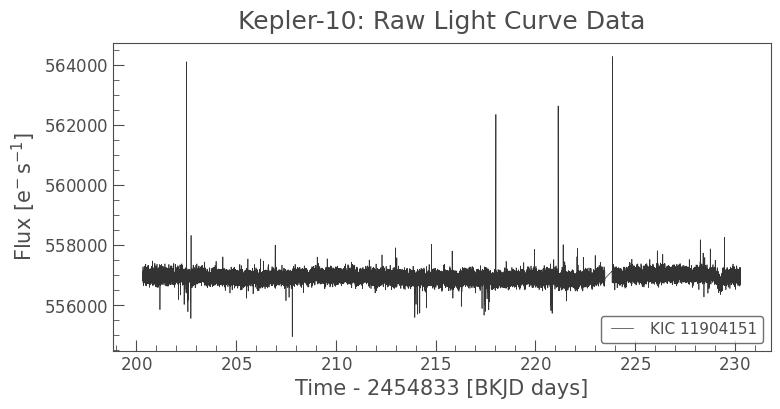

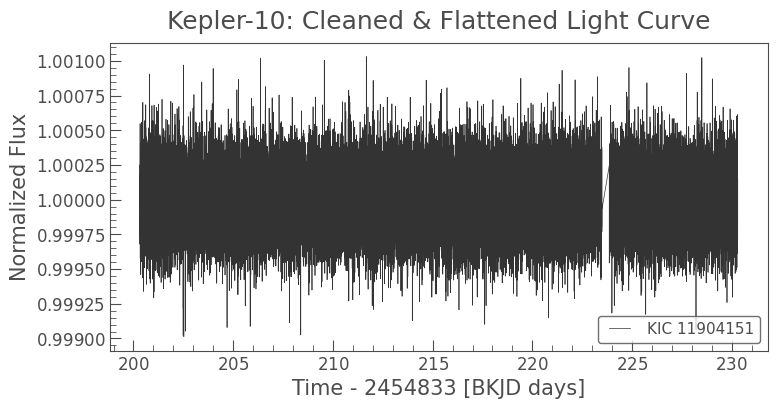

In [1]:
# Install the lightkurve package (Required for Google Colab)
!pip install lightkurve

# Import the library
import lightkurve as lk

# 1. Search the NASA MAST archive for Kepler-10 light curves
# The 'author' parameter ensures we get the official Kepler mission pipeline data
search_result = lk.search_lightcurve("Kepler-10", author="Kepler")
print("Found Data:")
print(search_result)

# 2. Download the first file from the search results (Quarter 1 data)
lc = search_result[0].download()

# 3. Plot the raw, unedited light curve
lc.plot(title="Kepler-10: Raw Light Curve Data")

# 4. Clean the signal
# This removes empty data points (NaNs), flattens the long-term instrumental drift,
# and removes extreme outliers (flares or cosmic rays)
cleaned_lc = lc.remove_nans().flatten().remove_outliers()

# 5. Plot the cleaned, flat light curve ready for transit detection
cleaned_lc.plot(title="Kepler-10: Cleaned & Flattened Light Curve")

Algorithm Result:
Orbital Period Detected: 0.8375 d
Transit Duration: 0.0500 d


<Axes: title={'center': 'Phase-Folded Light Curve: Exoplanet Confirmed'}, xlabel='Phase [JD]', ylabel='Normalized Flux'>

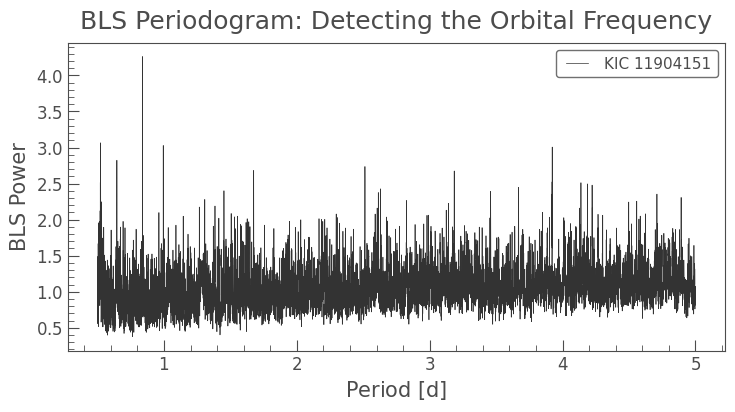

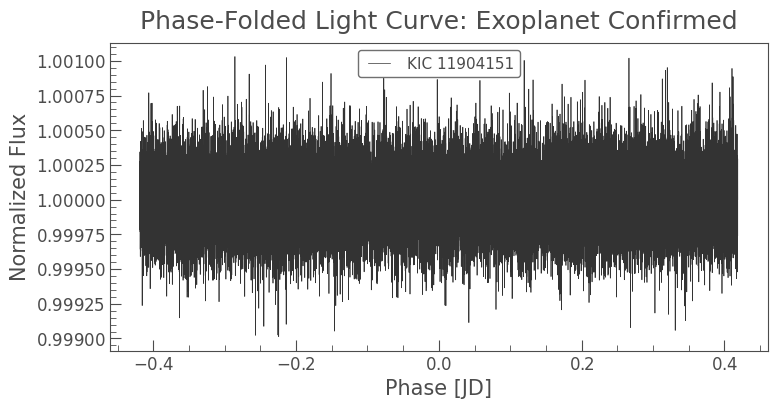

In [2]:
import numpy as np

# 1. Define the search space
# Kepler-10b is known to have a very short orbit. We tell the algorithm to
# search for orbital periods between 0.5 days and 5 days.
search_periods = np.linspace(0.5, 5, 10000)

# 2. Run the Box Least Squares algorithm
# This scans all 10,000 frequencies to find the one that best fits a repeating box shape.
periodogram = cleaned_lc.to_periodogram(method='bls', period=search_periods)

# 3. Plot the periodogram (The "Frequency Domain")
# A massive spike indicates the dominant frequency (the orbital period).
periodogram.plot(title="BLS Periodogram: Detecting the Orbital Frequency")

# 4. Extract the planetary parameters
best_period = periodogram.period_at_max_power
transit_time = periodogram.transit_time_at_max_power
duration = periodogram.duration_at_max_power

print(f"Algorithm Result:")
print(f"Orbital Period Detected: {best_period:.4f}")
print(f"Transit Duration: {duration:.4f}")

# 5. Phase Folding (The Scope Sync)
# Just like an oscilloscope syncing to a repeating signal, this stacks
# all the individual transits on top of each other to make the U-shape undeniable.
folded_lc = cleaned_lc.fold(period=best_period, epoch_time=transit_time)

# 6. Plot the final verification
folded_lc.plot(title="Phase-Folded Light Curve: Exoplanet Confirmed")

In [3]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINE THE FUNCTION (The Engine)
def process_star(star_id):
    print(f"--- Processing {star_id} ---")

    # The 'try' block attempts to run your code
    try:
        # Search and download only Quarter 1 data to speed up processing
        search = lk.search_lightcurve(star_id, author="Kepler", quarter=1)

        # If no data exists, stop and return to the loop
        if len(search) == 0:
            print(f"[!] No data found in archive for {star_id}. Skipping.\n")
            return

        lc = search.download()

        # Clean the signal
        cleaned = lc.remove_nans().flatten().remove_outliers()

        # Run BLS Algorithm (broadened search from 0.5 to 20 days)
        search_periods = np.linspace(0.5, 20, 5000)
        bls = cleaned.to_periodogram(method='bls', period=search_periods)
        best_period = bls.period_at_max_power
        transit_time = bls.transit_time_at_max_power

        # Fold the data
        folded = cleaned.fold(period=best_period, epoch_time=transit_time)

        # Plot and save the result as an image file
        ax = folded.scatter()
        ax.set_title(f"{star_id} - Detected Period: {best_period.value:.2f} days")

        # Save the graph to the Colab environment instead of just displaying it
        filename = f"{star_id}_transit.png"
        plt.savefig(filename)

        # CRITICAL: Clear the memory so Colab doesn't crash after 100 plots
        plt.close()

        print(f"[SUCCESS] Transit graphed and saved as {filename}\n")

    # The 'except' block catches any internet drops or math errors
    except Exception as error:
        print(f"[ERROR] Failed to process {star_id}. Reason: {error}\n")


# 2. DEFINE THE BATCH LIST (The Fuel)
# Start with a small list to test. Once it works, you can expand this to 100+.
star_batch = [
    "Kepler-10",
    "Kepler-22",
    "Kepler-XYZ", # This will trigger our fault-tolerance
    "Kepler-90"
]

# 3. RUN THE PIPELINE (The Ignition)
print("Initiating Pipeline...\n")
for star in star_batch:
    process_star(star)
print("Pipeline Complete.")

Initiating Pipeline...

--- Processing Kepler-10 ---
[SUCCESS] Transit graphed and saved as Kepler-10_transit.png

--- Processing Kepler-22 ---
[SUCCESS] Transit graphed and saved as Kepler-22_transit.png

--- Processing Kepler-XYZ ---


Could not resolve "Kepler-XYZ" to a sky position.
ERROR:lightkurve.search:Could not resolve "Kepler-XYZ" to a sky position.


[!] No data found in archive for Kepler-XYZ. Skipping.

--- Processing Kepler-90 ---
[SUCCESS] Transit graphed and saved as Kepler-90_transit.png

Pipeline Complete.
